In [1]:
import torch
import dgl

Iteration 1, Loss: 1.0000
Iteration 2, Loss: 0.9609
Iteration 3, Loss: 0.9234
Iteration 4, Loss: 0.8876
Iteration 5, Loss: 0.8535
Iteration 6, Loss: 0.8211
Iteration 7, Loss: 0.7904
Iteration 8, Loss: 0.7614
Iteration 9, Loss: 0.7341
Iteration 10, Loss: 0.7086

Final displacements:
tensor([[-0.0979, -0.0982],
        [-0.0832, -0.0705],
        [ 0.0981,  0.0983]])


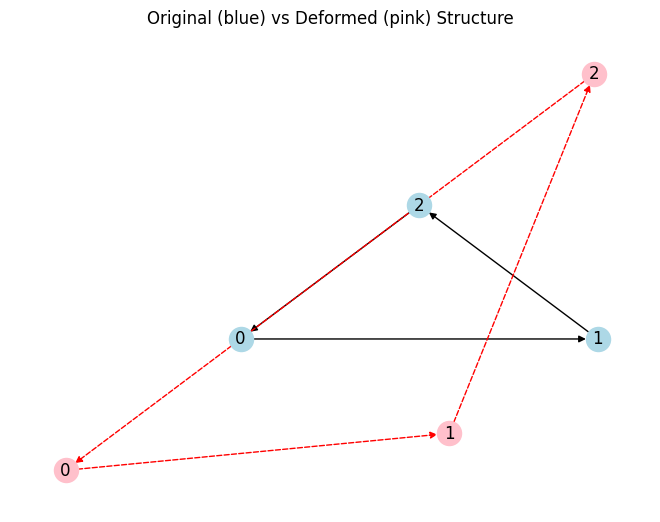

In [2]:
import torch
import dgl
import networkx as nx
import matplotlib.pyplot as plt

# 创建一个简单的杆件系统图
def build_truss_graph():
    # 创建图 - 这里使用一个简单的三角形桁架
    g = dgl.graph(([0, 1, 2], [1, 2, 0]))  # 边: 0-1, 1-2, 2-0
    
    # 设置节点特征 (位置和受力)
    # 每个节点的特征: [x_pos, y_pos, x_force, y_force]
    node_features = torch.tensor([
        [0.0, 0.0, 0.0, -1.0],  # 节点0: 位于(0,0), 受到向下1N的力
        [1.0, 0.0, 0.0, 0.0],    # 节点1: 位于(1,0), 无外力
        [0.5, 0.5, 0.0, 0.0]     # 节点2: 位于(0.5,0.5), 无外力
    ], dtype=torch.float32)
    
    # 设置边特征 (刚度)
    # 每条边的特征: [刚度]
    edge_features = torch.tensor([
        [1.0],  # 杆件0-1
        [1.0],  # 杆件1-2
        [1.0]   # 杆件2-0
    ], dtype=torch.float32)
    
    g.ndata['feat'] = node_features
    g.edata['feat'] = edge_features
    
    return g

# 定义message-passing函数
def message_func(edges):
    # 计算杆件向量
    src_pos = edges.src['feat'][:, :2]  # 源节点位置
    dst_pos = edges.dst['feat'][:, :2]  # 目标节点位置
    vec = dst_pos - src_pos  # 杆件方向向量
    
    # 计算杆件长度
    length = torch.norm(vec, dim=1, keepdim=True)
    unit_vec = vec / length  # 单位方向向量
    
    # 计算杆件力 (假设杆件力与变形成正比)
    stiffness = edges.data['feat']  # 杆件刚度
    displacement = edges.dst['displacement'] - edges.src['displacement']
    axial_deformation = torch.sum(displacement * unit_vec, dim=1, keepdim=True)
    force = stiffness * axial_deformation * unit_vec
    
    return {'force': force}

# 定义reduce函数 (累加所有邻接杆件的力)
def reduce_func(nodes):
    # 累加所有邻接杆件传递来的力
    accumulated_force = torch.sum(nodes.mailbox['force'], dim=1)
    
    # 计算残余力 (外力 - 内力)
    external_force = nodes.data['feat'][:, 2:]
    residual_force = external_force - accumulated_force
    
    return {'residual': residual_force}

# 力平衡求解
def solve_force_balance(graph, num_iters=10, learning_rate=0.01):
    # 初始化节点位移 (需要梯度)
    graph.ndata['displacement'] = torch.zeros(graph.number_of_nodes(), 2, 
                                             dtype=torch.float32, requires_grad=True)
    
    optimizer = torch.optim.Adam([graph.ndata['displacement']], lr=learning_rate)
    
    for i in range(num_iters):
        # 前向传播: message passing
        graph.update_all(message_func, reduce_func)
        
        # 计算损失 (残余力的L2范数)
        residual = graph.ndata['residual']
        loss = torch.sum(residual ** 2)
        
        # 反向传播
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        print(f"Iteration {i+1}, Loss: {loss.item():.4f}")
    
    return graph.ndata['displacement'].detach()

# 可视化结果
def visualize_graph(graph, displacements):
    nx_g = graph.to_networkx()
    pos = graph.ndata['feat'][:, :2].numpy()
    disp = displacements.numpy()
    
    # 绘制原始位置
    nx.draw(nx_g, pos, with_labels=True, node_color='lightblue')
    
    # 绘制位移后的位置
    deformed_pos = pos + disp * 5  # 放大位移以便观察
    nx.draw(nx_g, deformed_pos, with_labels=True, node_color='pink', edge_color='red', style='dashed')
    
    plt.title("Original (blue) vs Deformed (pink) Structure")
    plt.show()

# 主程序
if __name__ == "__main__":
    # 构建图
    g = build_truss_graph()
    
    # 求解力平衡
    displacements = solve_force_balance(g)
    print("\nFinal displacements:")
    print(displacements)
    
    # 可视化
    visualize_graph(g, displacements)